In [8]:
# import packages
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
import shap
import matplotlib.pyplot as plt

In [9]:
seed = 2724

### Import data

In [10]:
DF_PATH = "mod04_data/sample.csv"
df = pd.read_csv(DF_PATH)

### Separate data by independent (X) and dependent (y) variables

In [11]:
X = df[["income", "education_years", "zipcode_score"]]
y = df["target"]

### Split the data into a _training_ set (to build a model) and _test_ set (to validate a model)

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=seed
)

### Build a model on the training set

In [13]:
model = RandomForestRegressor(
    n_estimators=200,
    random_state=seed
)
model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=2724)

### Use SHAP to explain the model on test data

In [14]:
explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_test)

100%|===================| 1497/1500 [00:39<00:00]        

This will allow us to see which variables are most important to predicting the outcome.

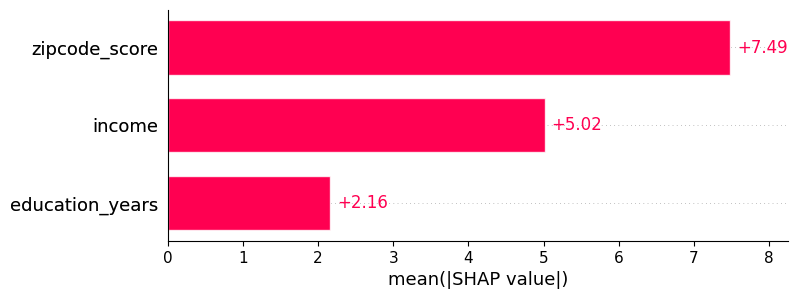

In [15]:
shap.plots.bar(shap_values)

### Import the `group` variable, which was **not** used in training this model.

In [16]:
X_test_with_group = X_test.copy()
X_test_with_group["group"] = df.loc[X_test.index, "group"]

### Look at the difference in SHAP values between the two groups across the variables used in the model.

In [17]:
shap_df = pd.DataFrame(shap_values.values, columns=X_test.columns)
shap_df["group"] = X_test_with_group["group"].values

shap_df.groupby("group").mean()

,income,education_years,zipcode_score
group,,,
0,1.086254,-0.170779,5.866534
1,1.020094,-0.192841,-6.859435


### Let's put `group` and `zipcode_score` in the same plot

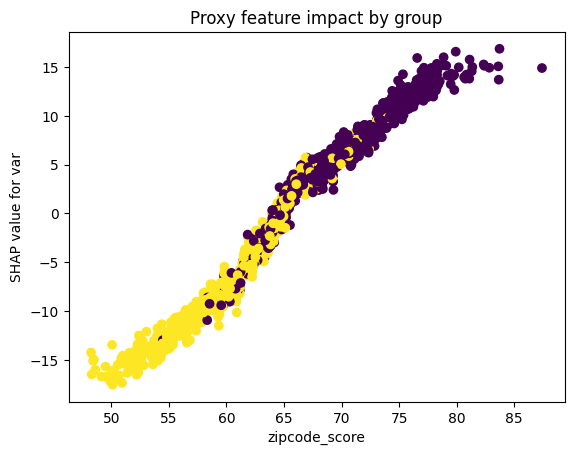

In [18]:
def plot_shap(var):
    # Extract SHAP values for the feature
    shap_var = shap_values[:, var].values

    # Plot the values of each group using different colors
    plt.figure()
    plt.scatter(
        X_test[var],
        shap_var,
        c=X_test_with_group["group"]
    )
    plt.xlabel(var)
    plt.ylabel(f"SHAP value for var")
    plt.title("Proxy feature impact by group")
    plt.show()

plot_shap("zipcode_score")

# Discussion Questions

### What is a _SHAP_ (or Shapley) value? 

SHAP is a method to explain individual predictions of a machine learning model. It is based on Shapley values from game theory, which fairly assign each feature a share of the model’s output.

A positive SHAP value → the feature increased the prediction for that instance; negative → it decreased it.
Summing all feature SHAP values (plus the base value) gives the model’s prediction for that instance.

### Suppose you built this model and then it is peer reviewed by another entity. If the reviewer asks whether you used the variable `group` in your model, what would your answer be?

I would answer no, the variable group was not used in the model. The model was trained only on income, education, and zipcode_score. It was added later only to the test set for post-hoc analysis (e.g., comparing SHAP values across groups), so the model itself does not take group as an input.

### If the reviewer asks whether the outcome of your model is correlated with `group`, what would your answer be?

I would answer say yes, even though group was not in the input. The SHAP analysis by group shows that average feature impacts differ strongly by group. So the inputs we did use—especially zipcode_score—act as proxies for group: they are associated with group, and the model relies on them, so predictions and their drivers differ systematically by group. So the model’s outcome is effectively correlated with group through those proxy features.

### Construct a "proxy feature impact by group" plot for `income`. How is this plot different from the one for `zipcode_score`?

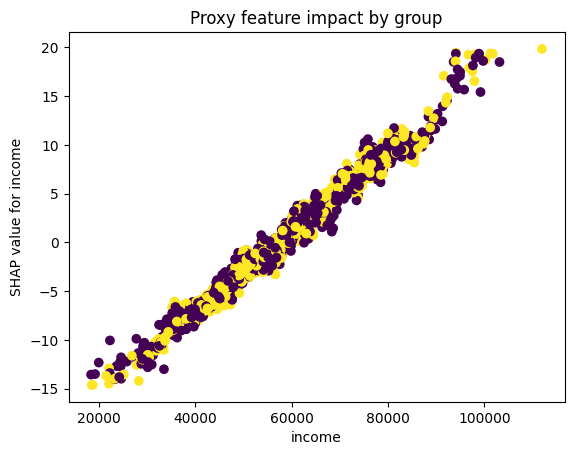

In [19]:
def plot_shap(var):
    shap_var = shap_values[:, var].values
    plt.figure()
    plt.scatter(
        X_test[var],
        shap_var,
        c=X_test_with_group["group"]
    )
    plt.xlabel(var)
    plt.ylabel(f"SHAP value for {var}")
    plt.title("Proxy feature impact by group")
    plt.show()

plot_shap("income")

For zipcode_score, the plot shows a clear split by group: one group tends to get strongly positive SHAP values and the other strongly negative, so the two groups are separated in the scatter (proxy feature impact differs a lot by group). For income, the mean SHAP values by group are both positive and similar, so the two groups overlap much more in the scatter—income pushes predictions up for both groups in a similar way. So the main difference is that zipcode_score acts as a strong proxy for group (opposite impacts by group), while income does not show that kind of group-wise split; the bias in the model’s behavior is largely driven by zipcode_score, not income.

### If, instead, you were the **reviewer**, what other questions might you ask the person who built this model? Give at least two.

1. “Did you check whether any of the input features (e.g., zipcode_score) are strongly correlated with protected or sensitive attributes like group? If so, how did you address the risk of proxy discrimination?”
2. “What is zipcode_score based on, and could it encode historical bias or redlining? Have you considered removing or replacing it with less proxy-linked features?”